## Imports

In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline


import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

import drjit as dr
import mitsuba as mi

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject


import numpy as np
import pickle
from scipy.io import savemat

In [2]:
# Load integrated scene
scene = load_scene(sionna.rt.scene.munich) # Try also sionna.rt.scene.etoile

In [3]:
if not no_preview:
    scene.preview();

In [4]:
# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

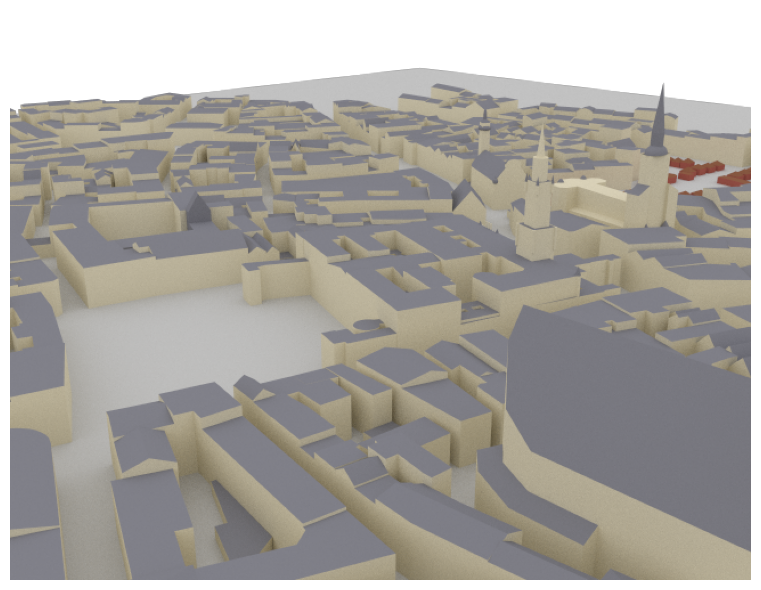

In [5]:
# Create new camera with different configuration
my_cam = Camera(position=[-250,250,150], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

In [6]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True) # Merge shapes to speed-up computations

# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

# Create transmitter
tx = Transmitter(name="tx",
                 position=[8.5,21,27],
                 display_radius=2)

# Add transmitter instance to scene
scene.add(tx)

# Create a receiver
rx = Receiver(name="rx",
              position=[45,90,1.5],
              display_radius=2)

# Add receiver instance to scene
scene.add(rx)

tx.look_at(rx) # Transmitter points towards receiver

In [7]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

The [Paths](https://nvlabs.github.io/sionna/rt/paths.html) object contains all paths that have been found between transmitters and receivers.
In principle, the existence of each path is determininistic for a given position and environment. Please note that due to the stochastic nature of the *shoot-and-bounce* algorithm, different runs of the path solver can lead to different paths that are found. Most importantly, diffusely reflected paths are obtained through random sampling of directions after each interaction with a scene object. You can provide the `seed` argument to the solver to ensure reproducibility.

Let us now visualize the found paths in the scene:

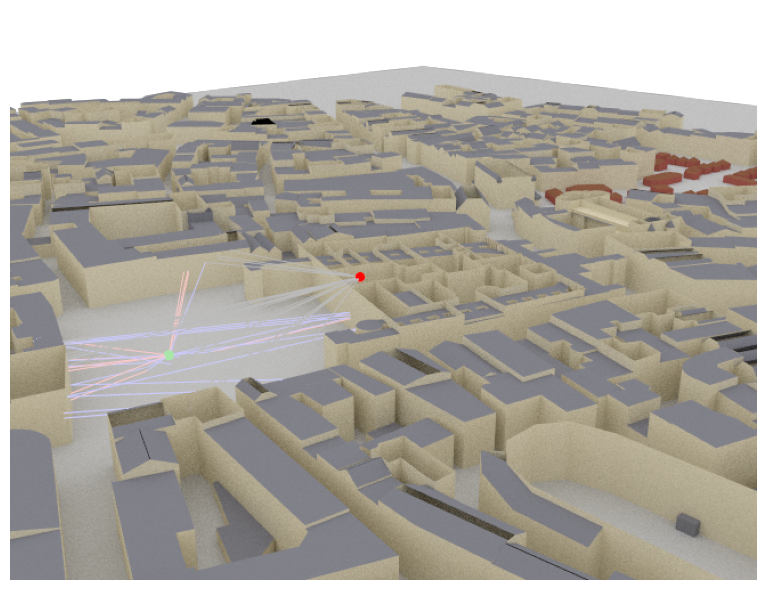

In [8]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);
else:
    scene.preview(paths=paths, clip_at=20);

The Paths object contains detailed information about every found path and allows us to generate channel impulse responses and apply Doppler shifts for the simulation of time evolution. For a detailed description, we refer to the developer guide [Understanding the Paths Object](https://nvlabs.github.io/sionna/rt/developer/dev_understanding_paths.html).

## From Paths to Channel Impulse and Frequency Responses

Once paths are computed, they can be transformed into a baseband-equivalent channel impulse response (CIR) via [Paths.cir()](https://nvlabs.github.io/sionna/rt/api/paths.html#sionna.rt.Paths.cir), into a discrete complex baseband-equivalent channel impulse response via [Paths.taps()](https://nvlabs.github.io/sionna/rt/api/paths.html#sionna.rt.Paths.taps), or into a channel frequency response (CFR) via
[Paths.cfr()](https://nvlabs.github.io/sionna/rt/api/paths.html#sionna.rt.Paths.cfr). These class methods can simulate time evolution of the channel based on the computed Doppler shifts (see [Paths.doppler](https://nvlabs.github.io/sionna/rt/api/paths.html#sionna.rt.Paths.doppler)).

Let us first derive and visualize the baseband-equivalent channel impulse response from the paths computed above:

In [9]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 1, 21, 1)
Shape of tau:  (1, 2, 1, 1, 21)


The `out_type` argument can be used to convert the CIR into tensors from different frameworks, such as [Dr.Jit](https://drjit.readthedocs.io/en/latest/reference.html) ("drjit"), [Numpy](https://numpy.org) ("numpy"),
            [Jax](https://jax.readthedocs.io/en/latest/index.html) ("jax"),
            [TensorFlow](https://www.tensorflow.org) ("tf"),
            and [PyTorch](https://pytorch.org) ("torch"). Please see the developer guide [Compatibility with other Frameworks](https://nvlabs.github.io/sionna/rt/developer/dev_compat_frameworks.html) for more information on the interoperability of Sionna RT with other array frameworks, including the propagation of gradients.

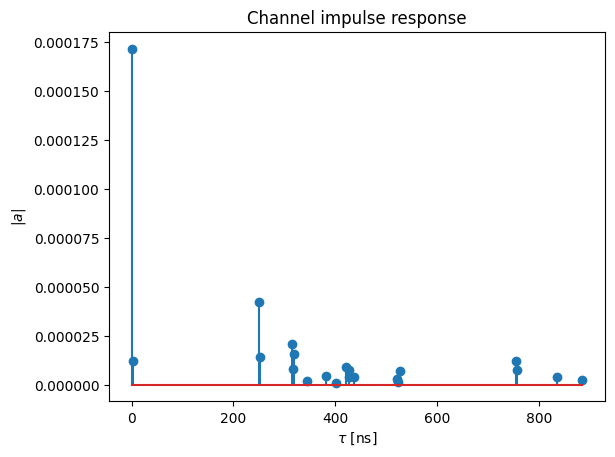

In [10]:
t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

Note that the delay of the first arriving path is by default normalized to zero. This behavior can be changed by setting the argument ``normalize_delays`` to `True`.

We can obtain the channel frequency response in a similar manner:

Shape of h_freq:  (1, 2, 1, 1, 1, 1024)


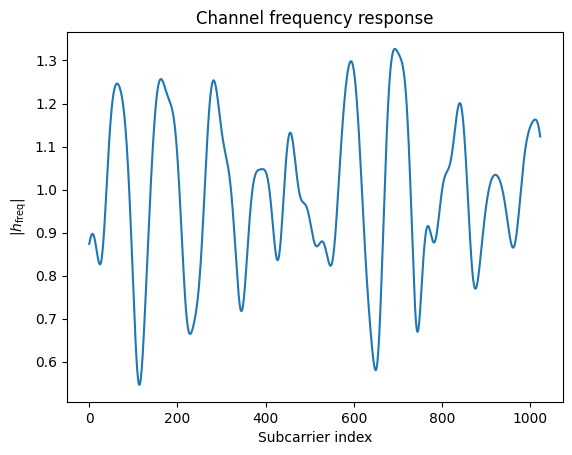

In [11]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

For link-level simulations in the time-domain, we often require the discrete baseband-equivalent channel impulse response or simply the channel taps.
These are obtained by sampling the ideally low-pass filtered channel impulse response at the desired sampling frequency. By default, it is assumed that sampling is performed at the Nyquist rate.

As the underlying sinc filter has an infinitely long response, the channel taps need to be truncated at a minimum and maximum value, i.e., `l_min` and `l_max`, respectively.

Shape of taps:  (1, 2, 1, 1, 1, 107)


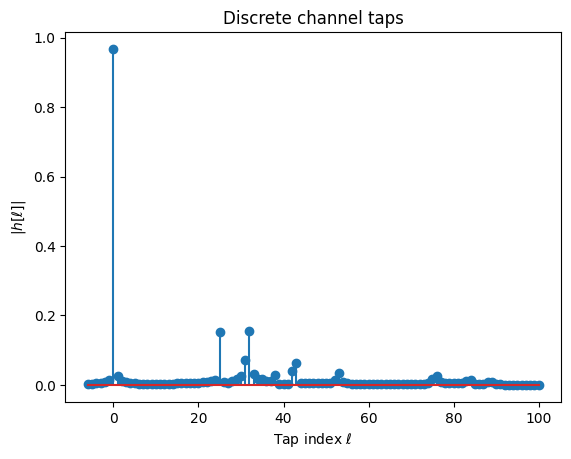

In [12]:
taps = paths.taps(bandwidth=100e6, # Bandwidth to which the channel is low-pass filtered
                  l_min=-6,        # Smallest time lag
                  l_max=100,       # Largest time lag
                  sampling_frequency=None, # Sampling at Nyquist rate, i.e., 1/bandwidth
                  normalize=True,  # Normalize energy
                  normalize_delays=True,
                  out_type="numpy")
print("Shape of taps: ", taps.shape)

plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");

Every radio device and scene object has a velocity vector associated with it. These are used to compute path-specific Doppler shifts that enable the simulation of mobility. More details can be found in the [Tutorial on Mobility](https://nvlabs.github.io/sionna/rt/tutorials/Mobility.html).

We will now assign a non-zero velocity vector to the transmitter, recompute the propagation paths, and compute a time-varying channel impulse reponse:

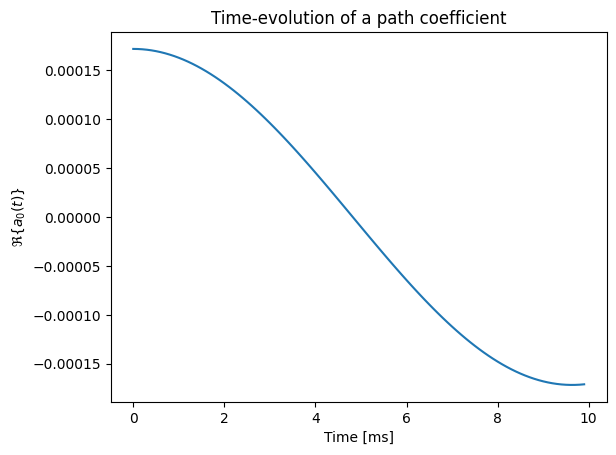

In [13]:
scene.get("tx").velocity = [10, 0, 0]

# Recompute propagation paths
paths_mob = p_solver(scene=scene,
                     max_depth=5,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=False,
                     refraction=True,
                     synthetic_array=True,
                     seed=41)

# Compute CIR with time-evolution
num_time_steps=100
sampling_frequency = 1e4
a_mob, _ = paths_mob.cir(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         out_type="numpy")

# Inspect time-evolution of a single path coefficient
plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

In [14]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True) # Merge shapes to speed-up computations

from sionna.rt import RadioMaterial

reflector_material = RadioMaterial(
    name="reflector-mat-2",
    conductivity=1e7,
    relative_permittivity=1.0
)

scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=4,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

# Radio material constituing the cars
# We use ITU metal, and use red color for visualization to
# make the cars easily discernible
car_material = ITURadioMaterial("car-material",
                                "metal",
                                thickness=0.01,
                                color=(0.8, 0.1, 0.1))

# Instantiate `num_cars` cars sharing the same mesh and material
cars = SceneObject(fname=sionna.rt.scene.low_poly_car, # Simple mesh of a car
                    name="car",
                    radio_material=car_material)

reflectors = SceneObject(
    fname="reflector.ply",
    name="reflector",
    radio_material=reflector_material
)

# Create transmitter
bs_tx = Transmitter(name="bs_tx",
                 position=[8.5,21,27],
                 display_radius=5)

# Add transmitter instance to scene
scene.add(bs_tx)

# Create a receiver
ue_rx = Receiver(name="ue_rx",
              position=[45,90,2],
              display_radius=2)

# Add receiver instance to scene
scene.add(ue_rx)

# Add the list of newly instantiated objects to the scene
scene.edit(add=cars)
scene.edit(add=reflectors)


cars.position = mi.Point3f(ue_rx.position[0], ue_rx.position[1], ue_rx.position[2]-1) # Place the cars at the same x-y position as the UE, but on the ground (z=0)
cars.look_at(bs_tx) # Make the cars point towards the center of the scene


reflectors.position = mi.Point3f(ue_rx.position[0]+50, ue_rx.position[1]+15, ue_rx.position[2]) # Place the reflector 10m away from the UE in x-direction
reflectors.look_at(bs_tx) # Make the reflector point towards the center of the scene
reflectors.orientation = reflectors.orientation + np.array([0, np.pi/2, 0])

bs_tx.look_at(ue_rx) # Transmitter points towards receiver

# Create a receiver
bs_rx = Receiver(name="bs_rx",
              position=bs_tx.position,
              display_radius=2)

# Add receiver instance to scene
scene.add(bs_rx)


# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()


paths = p_solver(
    scene=scene,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=False,
    synthetic_array=False,
    seed=np.random.randint(0, 100000)
)
no_preview = False  # Toggle to False to use the preview widget

if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);
else:
    scene.preview(paths=paths, clip_at=20);



Shape of a:  (2, 8, 1, 4, 13, 1)
Shape of tau:  (2, 8, 1, 4, 13)


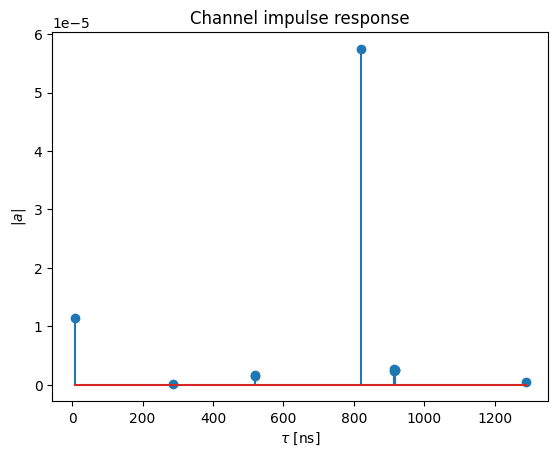

In [15]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

t = tau[1,0,0,0,:]/1e-9 # Scale to ns
ind = t > 0 # Only consider paths with positive delay
t = t[ind]
a_abs = np.abs(a)[1,0,0,0,:,0][ind]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

In [16]:
MOD_ORDER = 16
S, S_idx, constellation = generate_qam_symbols(
    N=N_MONTE_CARLO,
    K=1,
    M_order=MOD_ORDER,
    seed=12345
)

print("S shape:", S.shape)         # (N_MONTE_CARLO, 1)
print("S_idx shape:", S_idx.shape) # (N_MONTE_CARLO, 1)
print("Constellation:", constellation)

NameError: name 'generate_qam_symbols' is not defined

In [19]:

import drjit as dr
import mitsuba as mi
import numpy as np

def djit_scalar_to_float(v):
    """
    Convert Dr.Jit scalar (including AD scalar) to Python float.
    """
    v = dr.detach(v)
    a = np.asarray(v)
    if a.size == 1:
        return float(a.item())
    return float(a.reshape(-1)[0])

def vec3_from_obj(x):
    """
    Safely convert Mitsuba/Dr.Jit 3-vector to numpy shape (3,)
    """
    x = dr.detach(x)
    return np.array([
        djit_scalar_to_float(x[0]),
        djit_scalar_to_float(x[1]),
        djit_scalar_to_float(x[2]),
    ], dtype=np.float32)

def set_position(obj, xyz):
    xyz = np.asarray(xyz, dtype=np.float32).reshape(3)
    obj.position = mi.Point3f(
        float(xyz[0]), float(xyz[1]), float(xyz[2])
    )

def set_orientation(obj, ang):
    ang = np.asarray(ang, dtype=np.float32).reshape(3)
    obj.orientation = mi.Vector3f(
        float(ang[0]), float(ang[1]), float(ang[2])
    )

def collapse_cir_to_matrix(a_raw, tau_raw, fc_hz):
    """
    a_raw:   (M_rx, M_tx, P)
    tau_raw: (M_rx, M_tx, P)
    returns narrowband matrix: (M_rx, M_tx)
    """
    Hmat = np.zeros(a_raw.shape[:2], dtype=np.complex64)

    for m_rx in range(a_raw.shape[0]):
        for m_tx in range(a_raw.shape[1]):
            valid = tau_raw[m_rx, m_tx, :] >= 0
            if np.any(valid):
                Hmat[m_rx, m_tx] = np.sum(
                    a_raw[m_rx, m_tx, valid] *
                    np.exp(-1j * 2 * np.pi * fc_hz * tau_raw[m_rx, m_tx, valid])
                )
    return Hmat

def los_coeff_matrix(a_raw, tau_raw):
    """
    Return LOS coefficient a for each element by taking the valid path
    with minimum delay tau.
    Output: (M_rx, M_tx) complex64
    """
    G_los = np.zeros(a_raw.shape[:2], dtype=np.complex64)

    for m_rx in range(a_raw.shape[0]):
        for m_tx in range(a_raw.shape[1]):
            valid_idx = np.where(tau_raw[m_rx, m_tx, :] >= 0)[0]
            if valid_idx.size == 0:
                G_los[m_rx, m_tx] = 0.0 + 0.0j
                continue

            # minimum-delay path = LOS assumption
            tau_valid = tau_raw[m_rx, m_tx, valid_idx]
            los_local = valid_idx[np.argmin(tau_valid)]
            G_los[m_rx, m_tx] = np.complex64(a_raw[m_rx, m_tx, los_local])

    return G_los

def rician_kfactor_matrix(a_raw, tau_raw):
    """
    Compute per-element Rician K-factor:
        K = P_los / P_nlos
    using minimum-delay valid path as LOS.
    Output: (M_rx, M_tx) float32
    """
    Kmat = np.zeros(a_raw.shape[:2], dtype=np.float32)

    for m_rx in range(a_raw.shape[0]):
        for m_tx in range(a_raw.shape[1]):
            valid_idx = np.where(tau_raw[m_rx, m_tx, :] >= 0)[0]
            if valid_idx.size == 0:
                Kmat[m_rx, m_tx] = 0.0
                continue

            tau_valid = tau_raw[m_rx, m_tx, valid_idx]
            los_idx = valid_idx[np.argmin(tau_valid)]

            p_los = np.abs(a_raw[m_rx, m_tx, los_idx])**2

            nlos_idx = valid_idx[valid_idx != los_idx]
            if nlos_idx.size == 0:
                Kmat[m_rx, m_tx] = np.inf
            else:
                p_nlos = np.sum(np.abs(a_raw[m_rx, m_tx, nlos_idx])**2)
                if p_nlos == 0:
                    Kmat[m_rx, m_tx] = np.inf
                else:
                    Kmat[m_rx, m_tx] = np.float32(p_los / p_nlos)

    return Kmat

def solve_paths_current_scene(seed):
    return p_solver(
        scene=scene,
        max_depth=3,
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True,
        synthetic_array=False,
        seed=seed
    )

def solve_target_only(active_target, seed):
    """
    Solve sensing with only one target active:
      active_target in {"car", "reflector"}
    """
    if active_target == "car":
        scene.edit(remove=reflectors)
        try:
            paths = solve_paths_current_scene(seed)
        finally:
            scene.edit(add=reflectors)

    elif active_target == "reflector":
        scene.edit(remove=cars)
        try:
            paths = solve_paths_current_scene(seed)
        finally:
            scene.edit(add=cars)
    else:
        raise ValueError("active_target must be 'car' or 'reflector'")

    return paths

In [20]:
import numpy as np
import pickle
from scipy.io import savemat
import mitsuba as mi

# =========================================================
# Fixed setup 
# =========================================================
N_MONTE_CARLO = 100
K = 1
T = 2
M = 4
ARRAY_TYPE = "ULA_4x1"
SIGMA_POS = 1.0
SIGMA_ANGLE = 5.0

# =========================================================
# Force 4x1 array for both TX and RX (global scene arrays)
# =========================================================
scene.tx_array = PlanarArray(
    num_rows=4,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=4,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

FC = float(np.array(scene.frequency))
rng = np.random.default_rng(12345)


# =========================================================
# Save base states safely
# =========================================================
bs_tx_base_pos = vec3_from_obj(bs_tx.position)
bs_rx_base_pos = vec3_from_obj(bs_rx.position)
ue_rx_base_pos = vec3_from_obj(ue_rx.position)

bs_tx_base_ori = vec3_from_obj(bs_tx.orientation)
bs_rx_base_ori = vec3_from_obj(bs_rx.orientation)
ue_rx_base_ori = vec3_from_obj(ue_rx.orientation)

cars_base_pos = vec3_from_obj(cars.position)
cars_base_ori = vec3_from_obj(cars.orientation)

reflectors_base_pos = vec3_from_obj(reflectors.position)
reflectors_base_ori = vec3_from_obj(reflectors.orientation)

# =========================================================
# Dataset containers
# =========================================================
# Communication
H_a = np.empty((N_MONTE_CARLO,), dtype=object)              # raw a, shape (4,4,P) per sample
H_tau = np.empty((N_MONTE_CARLO,), dtype=object)            # raw tau, shape (4,4,P) per sample
H = np.zeros((N_MONTE_CARLO, M, M), dtype=np.float32)       # Rician K-factor matrix
H_matrix = np.zeros((N_MONTE_CARLO, M, M), dtype=np.complex64)  # transformed narrowband matrix

# Sensing
G_a = np.empty((N_MONTE_CARLO, T), dtype=object)            # raw a for each target
G_tau = np.empty((N_MONTE_CARLO, T), dtype=object)          # raw tau for each target
G = np.zeros((N_MONTE_CARLO, T, M, M), dtype=np.complex64)  # LOS coefficient a only

# Geometry
bs_tx_pos_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)
bs_rx_pos_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)
ue_rx_pos_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)

bs_tx_ori_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)
bs_rx_ori_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)
ue_rx_ori_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)

cars_pos_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)
reflectors_pos_dataset = np.zeros((N_MONTE_CARLO, 3), dtype=np.float32)

# =========================================================
# Monte Carlo loop
# =========================================================
for n in range(N_MONTE_CARLO):

    # -----------------------------------------------------
    # Perturb BS-TX and BS-RX together
    # -----------------------------------------------------
    delta_bs_pos = rng.uniform(-SIGMA_POS, SIGMA_POS, size=3).astype(np.float32)
    delta_bs_ori = np.deg2rad(
        rng.uniform(-SIGMA_ANGLE, SIGMA_ANGLE, size=3)
    ).astype(np.float32)

    set_position(bs_tx, bs_tx_base_pos + delta_bs_pos)
    set_position(bs_rx, bs_rx_base_pos + delta_bs_pos)

    set_orientation(bs_tx, bs_tx_base_ori + delta_bs_ori)
    set_orientation(bs_rx, bs_rx_base_ori + delta_bs_ori)

    # -----------------------------------------------------
    # Perturb UE independently
    # -----------------------------------------------------
    delta_ue_pos = rng.uniform(-SIGMA_POS, SIGMA_POS, size=3).astype(np.float32)
    delta_ue_ori = np.deg2rad(
        rng.uniform(-SIGMA_ANGLE, SIGMA_ANGLE, size=3)
    ).astype(np.float32)

    set_position(ue_rx, ue_rx_base_pos + delta_ue_pos)
    set_orientation(ue_rx, ue_rx_base_ori + delta_ue_ori)

    # -----------------------------------------------------
    # Targets fixed exactly as in the scene
    # -----------------------------------------------------
    set_position(cars, cars_base_pos)
    set_orientation(cars, cars_base_ori)

    set_position(reflectors, reflectors_base_pos)
    set_orientation(reflectors, reflectors_base_ori)

    # -----------------------------------------------------
    # Save geometry/orientation safely
    # -----------------------------------------------------
    bs_tx_pos_dataset[n] = vec3_from_obj(bs_tx.position)
    bs_rx_pos_dataset[n] = vec3_from_obj(bs_rx.position)
    ue_rx_pos_dataset[n] = vec3_from_obj(ue_rx.position)

    bs_tx_ori_dataset[n] = vec3_from_obj(bs_tx.orientation)
    bs_rx_ori_dataset[n] = vec3_from_obj(bs_rx.orientation)
    ue_rx_ori_dataset[n] = vec3_from_obj(ue_rx.orientation)

    cars_pos_dataset[n] = vec3_from_obj(cars.position)
    reflectors_pos_dataset[n] = vec3_from_obj(reflectors.position)

    # =====================================================
    # Communication: full scene, bs_tx -> ue_rx
    # =====================================================
    paths_full = solve_paths_current_scene(int(rng.integers(0, 100000)))

    a_full, tau_full = paths_full.cir(out_type="numpy")
    a_full = np.asarray(a_full)
    tau_full = np.asarray(tau_full)

    # receiver index 0 = ue_rx
    a_comm_raw = a_full[0, :, 0, :, :, 0]     # (4,4,P)
    tau_comm_raw = tau_full[0, :, 0, :, :]    # (4,4,P)

    H_a[n] = a_comm_raw.astype(np.complex64)
    H_tau[n] = tau_comm_raw.astype(np.float32)

    # transformed narrowband channel matrix
    H_matrix[n] = collapse_cir_to_matrix(a_comm_raw, tau_comm_raw, FC)

    # Rician K-factor per element
    H[n] = rician_kfactor_matrix(a_comm_raw, tau_comm_raw)

    # =====================================================
    # Sensing: one target at a time, bs_tx -> bs_rx
    # Save only LOS coefficient a into G
    # =====================================================
    target_names = ["car", "reflector"]

    for t, target_name in enumerate(target_names):
        paths_target = solve_target_only(target_name, int(rng.integers(0, 100000)))

        a_t, tau_t = paths_target.cir(out_type="numpy")
        a_t = np.asarray(a_t)
        tau_t = np.asarray(tau_t)

        # receiver index 1 = bs_rx
        a_sens_raw = a_t[1, :, 0, :, :, 0]      # (4,4,P)
        tau_sens_raw = tau_t[1, :, 0, :, :]     # (4,4,P)

        G_a[n, t] = a_sens_raw.astype(np.complex64)
        G_tau[n, t] = tau_sens_raw.astype(np.float32)

        # only LOS coefficient a
        G[n, t] = los_coeff_matrix(a_sens_raw, tau_sens_raw)


C:\Users\amirh\AppData\Local\Temp\ipykernel_103404\4061326791.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  FC = float(np.array(scene.frequency))


In [21]:
def generate_qam_symbols(N, K=1, M_order=16, seed=12345):
    """
    Generate modulated QAM signal matrix S with shape (N, K)

    Parameters
    ----------
    N : int
        Number of samples
    K : int
        Number of users
    M_order : int
        QAM order, e.g., 4, 16, 64
    seed : int
        Random seed

    Returns
    -------
    S : np.ndarray
        Complex QAM symbols, shape (N, K)
    bits : np.ndarray
        Integer symbol indices, shape (N, K)
    constellation : np.ndarray
        Normalized QAM constellation points
    """
    rng = np.random.default_rng(seed)

    m_side = int(np.sqrt(M_order))
    if m_side * m_side != M_order:
        raise ValueError("M_order must be a square QAM order like 4, 16, 64")

    # Square QAM grid
    levels = np.arange(-(m_side - 1), m_side, 2)
    constellation = np.array(
        [x + 1j * y for y in levels[::-1] for x in levels],
        dtype=np.complex64
    )

    # Normalize average power to 1
    constellation = constellation / np.sqrt(np.mean(np.abs(constellation)**2))

    # Random symbol indices
    bits = rng.integers(0, M_order, size=(N, K))

    # Map to constellation
    S = constellation[bits]

    return S.astype(np.complex64), bits.astype(np.int32), constellation

In [22]:
MOD_ORDER = 16
S, S_idx, constellation = generate_qam_symbols(
    N=N_MONTE_CARLO,
    K=1,
    M_order=MOD_ORDER,
    seed=12345
)

print("S shape:", S.shape)         # (N_MONTE_CARLO, 1)
print("S_idx shape:", S_idx.shape) # (N_MONTE_CARLO, 1)
print("Constellation:", constellation)

S shape: (100, 1)
S_idx shape: (100, 1)
Constellation: [-0.94868326+0.94868326j -0.31622776+0.94868326j  0.31622776+0.94868326j
  0.94868326+0.94868326j -0.94868326+0.31622776j -0.31622776+0.31622776j
  0.31622776+0.31622776j  0.94868326+0.31622776j -0.94868326-0.31622776j
 -0.31622776-0.31622776j  0.31622776-0.31622776j  0.94868326-0.31622776j
 -0.94868326-0.94868326j -0.31622776-0.94868326j  0.31622776-0.94868326j
  0.94868326-0.94868326j]


In [23]:

# =========================================================
# Final dataset
# =========================================================
dataset = {
    "H_a": H_a,
    "H_tau": H_tau,
    "H": H,                       # Rician K-factor, shape (N,4,4)
    "H_matrix": H_matrix,         # transformed narrowband matrix, shape (N,4,4)

    "G_a": G_a,
    "G_tau": G_tau,
    "G": G,                       # LOS coefficient only, shape (N,2,4,4)

    "bs_tx_position": bs_tx_pos_dataset,
    "bs_rx_position": bs_rx_pos_dataset,
    "ue_rx_position": ue_rx_pos_dataset,

    "bs_tx_orientation": bs_tx_ori_dataset,
    "bs_rx_orientation": bs_rx_ori_dataset,
    "ue_rx_orientation": ue_rx_ori_dataset,

    "cars_position": cars_pos_dataset,
    "reflectors_position": reflectors_pos_dataset,

    "S": S,                       # Modulated symbols for communication, shape (N, K)

    "meta": {
        "N": N_MONTE_CARLO,
        "K": K,
        "T": T,
        "M": M,
        "array_type": ARRAY_TYPE,
        "frequency_hz": FC,
        "H_shape": H.shape,
        "H_matrix_shape": H_matrix.shape,
        "G_shape": G.shape,
        "note": (
            "H stores per-element Rician K-factor. "
            "G stores only LOS coefficient a. "
            "Because bs_tx and bs_rx are co-located, LOS in sensing is typically direct leakage."
        )
    }
}

# =========================================================
# Save PKL
# =========================================================
with open("isac_dataset.pkl", "wb") as f:
    pickle.dump(dataset, f)

# =========================================================
# Save MAT
# Object arrays become MATLAB cell arrays
# =========================================================
mat_dict = {
    "H_a": H_a,
    "H_tau": H_tau,
    "H": H,
    "H_matrix": H_matrix,

    "G_a": G_a,
    "G_tau": G_tau,
    "G": G,

    "S": S,

    "bs_tx_position": bs_tx_pos_dataset,
    "bs_rx_position": bs_rx_pos_dataset,
    "ue_rx_position": ue_rx_pos_dataset,

    "bs_tx_orientation": bs_tx_ori_dataset,
    "bs_rx_orientation": bs_rx_ori_dataset,
    "ue_rx_orientation": ue_rx_ori_dataset,

    "cars_position": cars_pos_dataset,
    "reflectors_position": reflectors_pos_dataset,

    "N": np.array([[N_MONTE_CARLO]], dtype=np.int32),
    "K": np.array([[K]], dtype=np.int32),
    "T": np.array([[T]], dtype=np.int32),
    "M": np.array([[M]], dtype=np.int32),
    "frequency_hz": np.array([[FC]], dtype=np.float64),
    "array_type": ARRAY_TYPE,
}

savemat("isac_dataset.mat", mat_dict)

print("Saved:")
print("  isac_dataset.pkl")
print("  isac_dataset.mat")
print("H shape:", H.shape)
print("H_matrix shape:", H_matrix.shape)
print("G shape:", G.shape)

Saved:
  isac_dataset.pkl
  isac_dataset.mat
H shape: (100, 4, 4)
H_matrix shape: (100, 4, 4)
G shape: (100, 2, 4, 4)
